# ZEEL Stock Price Forecasting using LSTM

The goal here is to predict all 11 features of ZEEL (Zee Entertainment) stock for the next 5 trading days, using the last 5 days of data as input. I used an LSTM for this since it handles sequential/time-series data pretty well.

**-------- Roughly what the notebook does, in order: --------**
1. Load the data and do some basic EDA
2. Check for outliers (boxplots + IQR)
3. Clean and scale the features
4. Build sequences (10-day input → 5-day output)
5. Split into train / val / test (proper 3-way, no leakage)
6. Train the LSTM with early stopping
7. Evaluate with multiple metrics (MSE, RMSE, MAE, R², MAPE, directional accuracy)
8. Save the model


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [43]:
## Reproducibility — Seed Setup
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"All seeds set to {SEED}")

All seeds set to 42


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Loading the Data + EDA

In [45]:
df = pd.read_csv("ZEEL.csv")

In [46]:
print("Shape: ", df.shape)
df.head(20)

Shape:  (5306, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,ZEETELE,EQ,1092.55,1175.00,1179.95,1160.00,1179.95,1179.95,1177.03,1261391,1.484690e+14,NaN,NaN,NaN
1,2000-01-04,ZEETELE,EQ,1179.95,1220.00,1274.35,1183.10,1274.35,1260.65,1228.02,4616547,5.669220e+14,NaN,NaN,NaN
2,2000-01-05,ZEETELE,EQ,1260.65,1160.55,1317.70,1159.80,1190.95,1176.55,1238.35,8763127,1.085178e+15,NaN,NaN,NaN
3,2000-01-06,ZEETELE,EQ,1176.55,1195.00,1200.00,1095.00,1106.00,1115.45,1135.04,5164020,5.861353e+14,NaN,NaN,NaN
4,2000-01-07,ZEETELE,EQ,1115.45,1097.10,1097.10,1026.25,1026.25,1026.25,1029.94,755129,7.777374e+13,NaN,NaN,NaN
5,2000-01-10,ZEETELE,EQ,1026.25,1026.25,1026.25,944.30,962.00,966.70,980.49,3942813,3.865885e+14,NaN,NaN,NaN
6,2000-01-11,ZEETELE,EQ,966.70,985.00,1044.00,891.00,1018.80,1019.95,995.97,6802005,6.774605e+14,NaN,NaN,NaN
7,2000-01-12,ZEETELE,EQ,1019.95,1035.00,1088.00,1035.00,1064.00,1063.85,1068.99,2968833,3.173653e+14,NaN,NaN,NaN
8,2000-01-13,ZEETELE,EQ,1063.85,1073.00,1085.00,1012.70,1018.00,1023.10,1050.57,2251046,2.364882e+14,NaN,NaN,NaN
9,2000-01-14,ZEETELE,EQ,1023.10,1030.00,1034.75,980.70,1001.00,1001.85,1007.74,2949092,2.971906e+14,NaN,NaN,NaN


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   object 
 1   Symbol              5306 non-null   object 
 2   Series              5306 non-null   object 
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4787 non-null   float64
 14  %Deliverble         4787 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 621.9

In [48]:
df.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,2.456000e+03,4.787000e+03,4787.000000
mean,273.404495,273.974746,279.588862,267.593969,273.184075,273.233566,273.627346,4.825422e+06,1.249096e+14,6.264571e+04,1.415718e+06,0.452211
std,176.403117,177.386116,181.264300,172.365778,176.006686,176.048287,176.843638,8.402019e+06,2.190916e+14,7.267494e+04,1.959727e+06,0.185907
min,62.300000,62.000000,66.300000,60.100000,62.700000,62.300000,63.080000,4.415000e+03,7.021150e+10,2.960000e+02,4.415000e+03,0.055700
25%,143.200000,144.000000,146.950000,140.000000,143.500000,143.200000,143.680000,1.218226e+06,2.594652e+13,2.457875e+04,5.136865e+05,0.307300
50%,238.200000,238.000000,244.000000,231.450000,237.675000,238.125000,238.895000,2.138807e+06,5.249890e+13,4.107400e+04,8.935320e+05,0.463500
75%,345.637500,345.975000,352.800000,338.400000,345.050000,345.587500,345.637500,4.532904e+06,1.136967e+14,7.146250e+04,1.593444e+06,0.593900
max,1541.700000,1640.000000,1645.000000,1512.250000,1564.000000,1541.700000,1578.110000,1.659597e+08,4.285622e+15,1.088460e+06,4.289143e+07,1.000000


In [49]:
df.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [50]:
df.drop(columns=["Symbol", "Series"], inplace=True)  # not useful for forecasting

In [51]:
df.head(5)

,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,1092.55,1175.00,1179.95,1160.00,1179.95,1179.95,1177.03,1261391,1.484690e+14,NaN,NaN,NaN
1,2000-01-04,1179.95,1220.00,1274.35,1183.10,1274.35,1260.65,1228.02,4616547,5.669220e+14,NaN,NaN,NaN
2,2000-01-05,1260.65,1160.55,1317.70,1159.80,1190.95,1176.55,1238.35,8763127,1.085178e+15,NaN,NaN,NaN
3,2000-01-06,1176.55,1195.00,1200.00,1095.00,1106.00,1115.45,1135.04,5164020,5.861353e+14,NaN,NaN,NaN
4,2000-01-07,1115.45,1097.10,1097.10,1026.25,1026.25,1026.25,1029.94,755129,7.777374e+13,NaN,NaN,NaN


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   object 
 1   Prev Close          5306 non-null   float64
 2   Open                5306 non-null   float64
 3   High                5306 non-null   float64
 4   Low                 5306 non-null   float64
 5   Last                5306 non-null   float64
 6   Close               5306 non-null   float64
 7   VWAP                5306 non-null   float64
 8   Volume              5306 non-null   int64  
 9   Turnover            5306 non-null   float64
 10  Trades              2456 non-null   float64
 11  Deliverable Volume  4787 non-null   float64
 12  %Deliverble         4787 non-null   float64
dtypes: float64(11), int64(1), object(1)
memory usage: 539.0+ KB


In [53]:
df["Date"] = pd.to_datetime(df["Date"])  # was stored as string, need proper datetime
df.dropna(subset=["Date"], inplace=True)

In [54]:
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                5306 non-null   datetime64[ns]
 1   Prev Close          5306 non-null   float64       
 2   Open                5306 non-null   float64       
 3   High                5306 non-null   float64       
 4   Low                 5306 non-null   float64       
 5   Last                5306 non-null   float64       
 6   Close               5306 non-null   float64       
 7   VWAP                5306 non-null   float64       
 8   Volume              5306 non-null   int64         
 9   Turnover            5306 non-null   float64       
 10  Trades              2456 non-null   float64       
 11  Deliverable Volume  4787 non-null   float64       
 12  %Deliverble         4787 non-null   float64       
dtypes: datetime64[ns](1), float64(11), int64(1)
memo

In [56]:
length = len(df)
df.drop_duplicates(subset="Date", inplace=True)
print(f"Duplicates removed: {length - len(df)}")

Duplicates removed: 0


In [57]:
df

,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,1092.55,1175.00,1179.95,1160.00,1179.95,1179.95,1177.03,1261391,1.484690e+14,NaN,NaN,NaN
1,2000-01-04,1179.95,1220.00,1274.35,1183.10,1274.35,1260.65,1228.02,4616547,5.669220e+14,NaN,NaN,NaN
2,2000-01-05,1260.65,1160.55,1317.70,1159.80,1190.95,1176.55,1238.35,8763127,1.085178e+15,NaN,NaN,NaN
3,2000-01-06,1176.55,1195.00,1200.00,1095.00,1106.00,1115.45,1135.04,5164020,5.861353e+14,NaN,NaN,NaN
4,2000-01-07,1115.45,1097.10,1097.10,1026.25,1026.25,1026.25,1029.94,755129,7.777374e+13,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5301,2021-04-26,188.00,190.60,191.10,185.10,186.70,186.40,187.35,8542755,1.600451e+14,52374.0,2340188.0,0.2739
5302,2021-04-27,186.40,188.00,192.95,186.80,188.80,188.15,189.41,14247767,2.698636e+14,73673.0,5425957.0,0.3808
5303,2021-04-28,188.15,188.80,190.60,187.10,188.95,189.10,188.85,8429439,1.591917e+14,44056.0,2413974.0,0.2864
5304,2021-04-29,189.10,190.80,191.65,186.00,186.60,186.55,187.44,9483009,1.777471e+14,60932.0,2744472.0,0.2894


<Axes: >

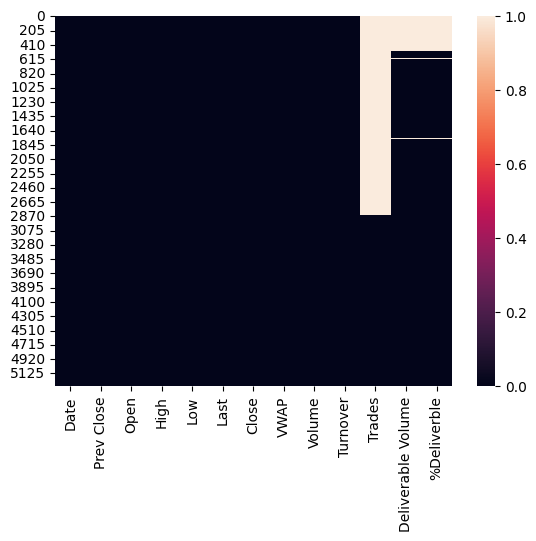

In [58]:
sns.heatmap(df.isnull())

In [59]:
df.isnull().sum()

Date                     0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     519
%Deliverble            519
dtype: int64

NaN counts BEFORE filling:
Date                     0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     519
%Deliverble            519
dtype: int64

%Deliverble NaN count: 519

NaN counts AFTER filling: 0


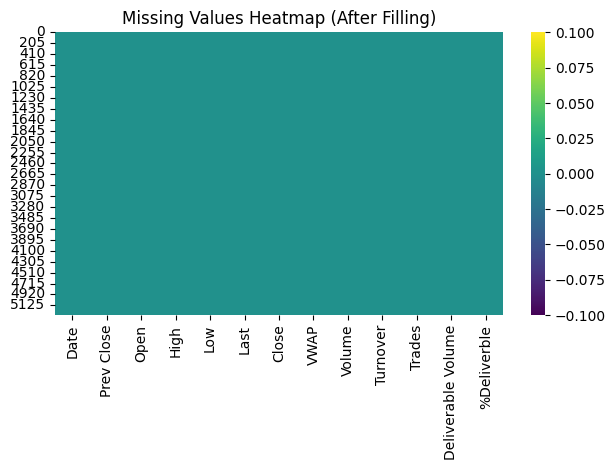

In [60]:
# A few NaNs in the dataset. I'm using forward-fill first, then backward-fill to catch anything at the start. 

print("NaN counts BEFORE filling:")
print(df.isnull().sum())
print(f"\n%Deliverble NaN count: {df['%Deliverble'].isnull().sum()}")

df.ffill(inplace=True)
df.bfill(inplace=True)
print("\nNaN counts AFTER filling:", df.isnull().sum().sum())

sns.heatmap(df.isnull(), cmap="viridis")
plt.title("Missing Values Heatmap (After Filling)")
plt.tight_layout()
plt.show()

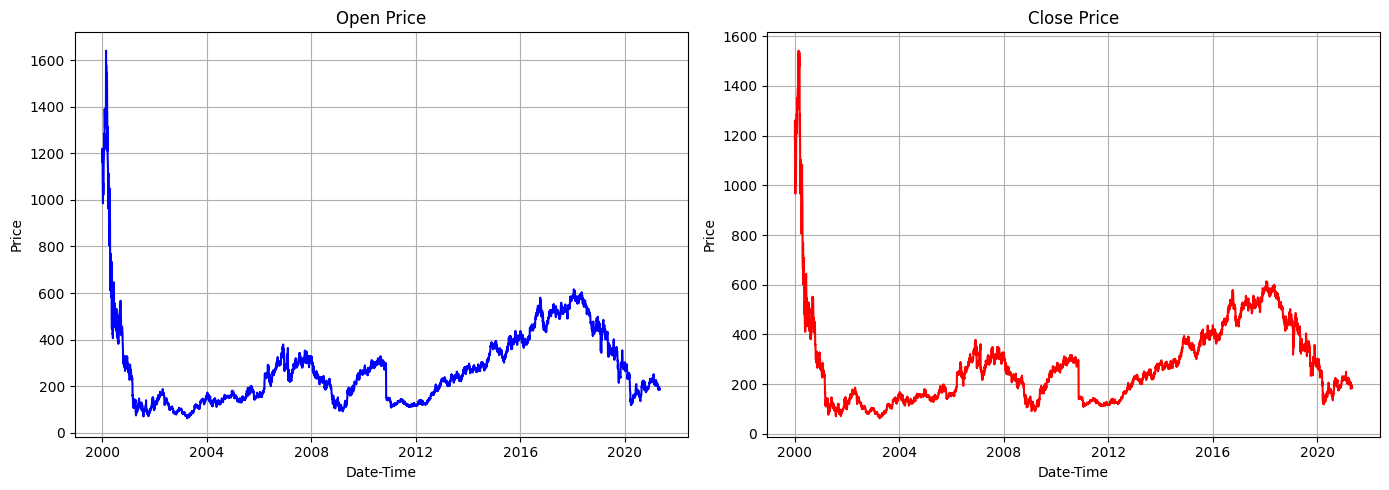

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['Date'], df['Open'],  color='blue')
axes[0].set_title('Open Price')
axes[0].set_xlabel('Date-Time')
axes[0].set_ylabel('Price')
axes[0].grid()

axes[1].plot(df['Date'], df['Close'], color='red')
axes[1].set_title('Close Price')
axes[1].set_xlabel('Date-Time')
axes[1].set_ylabel('Price')
axes[1].grid()

plt.tight_layout()
plt.show()

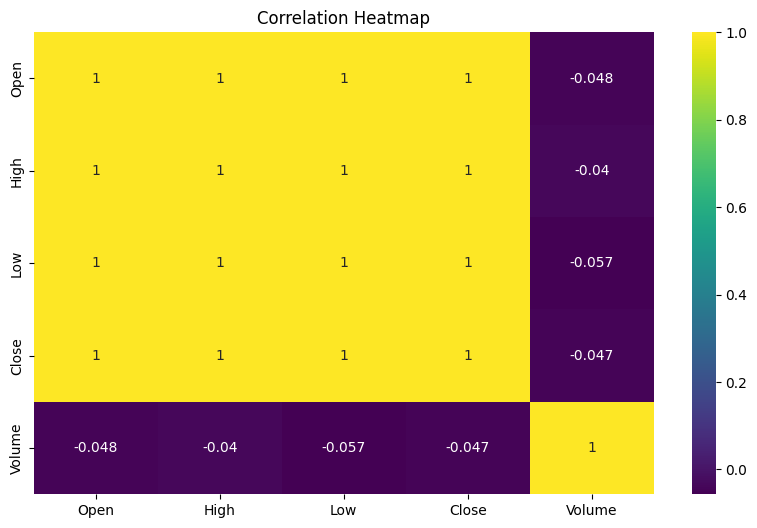

In [62]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(),
            annot=True, cmap='viridis')
plt.title('Correlation Heatmap')
plt.show()

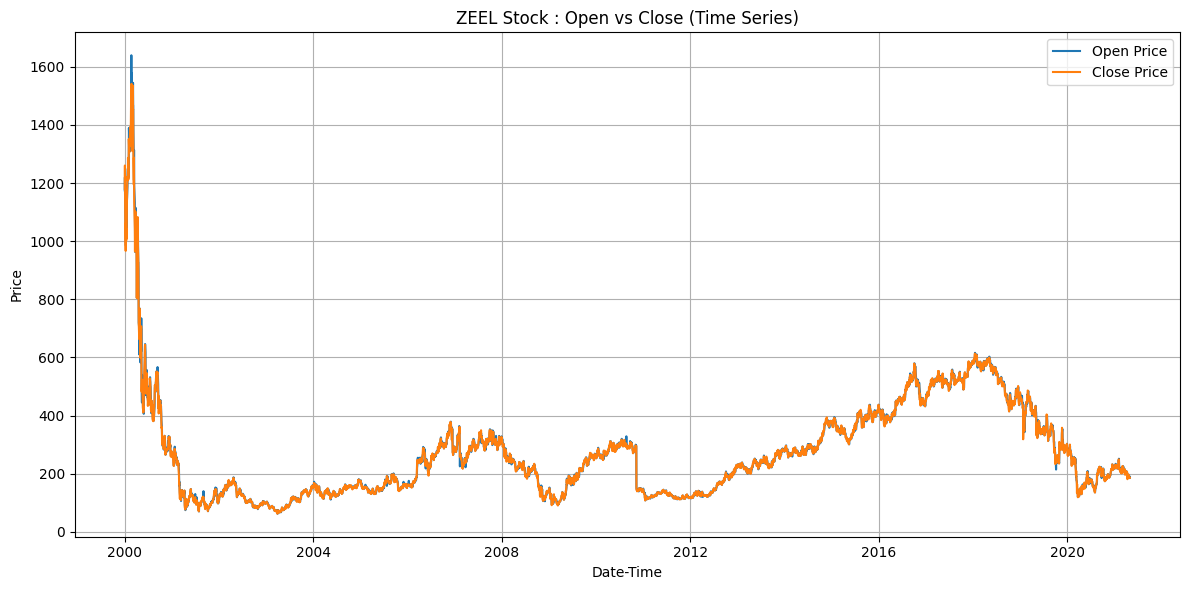

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Open'],  label='Open Price')
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.xlabel('Date-Time')
plt.ylabel('Price')
plt.title('ZEEL Stock : Open vs Close (Time Series)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Outlier Detection

Plotting boxplots for all the numeric columns to visually spot outliers. I'm also running the standard IQR rule to get actual counts.

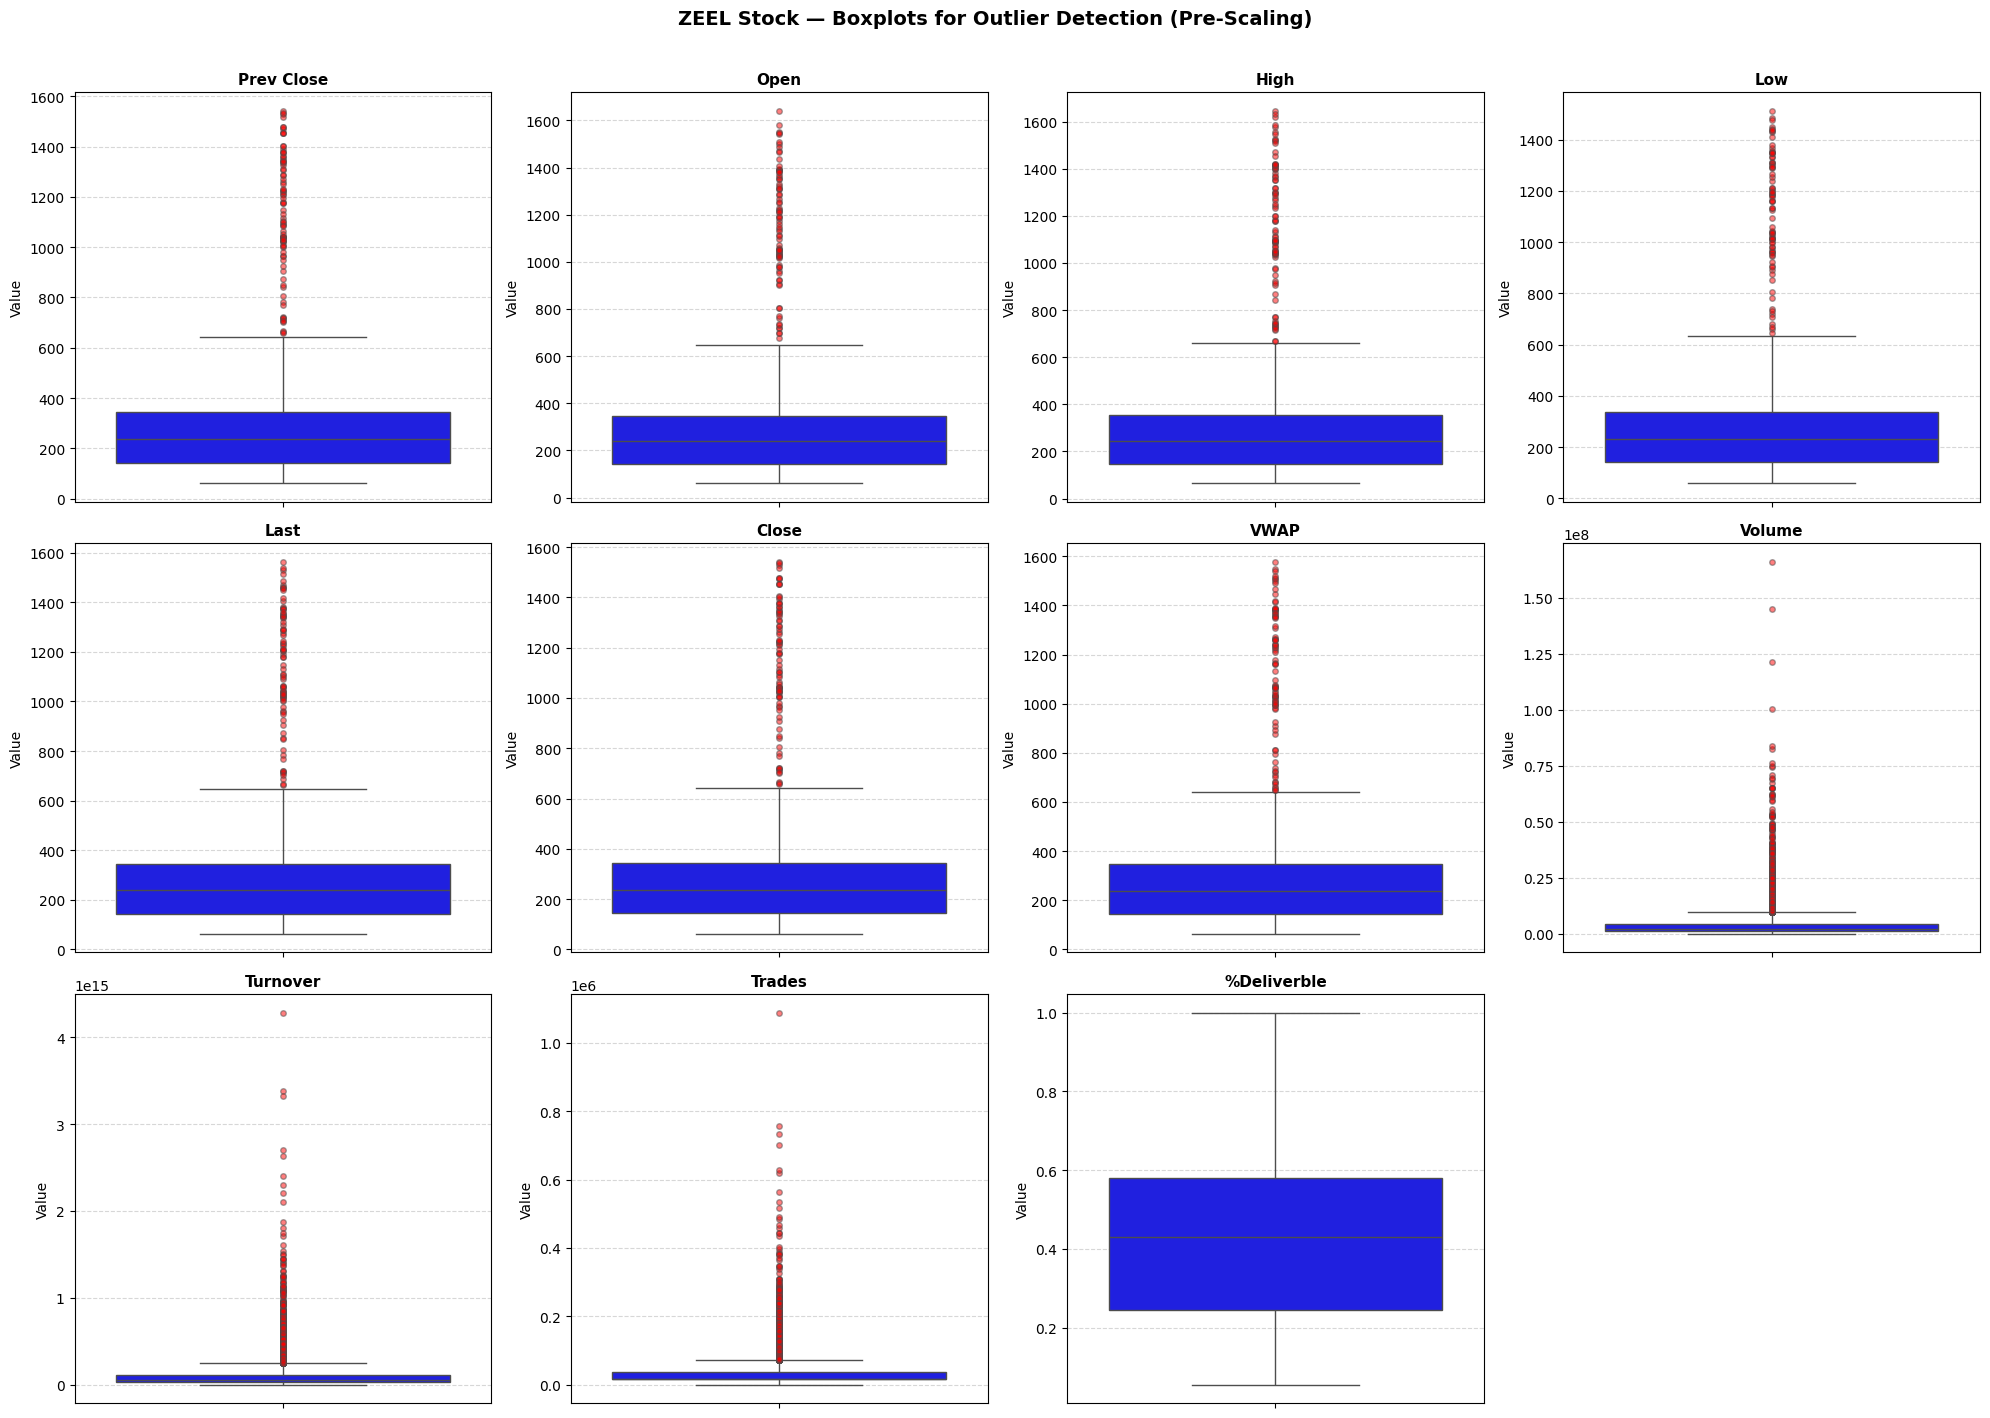


--- Outlier Counts (IQR, 1.5x rule) ---
Prev Close          :   85 outliers  (1.6%)
Open                :   83 outliers  (1.6%)
High                :   87 outliers  (1.6%)
Low                 :   81 outliers  (1.5%)
Last                :   83 outliers  (1.6%)
Close               :   84 outliers  (1.6%)
VWAP                :   87 outliers  (1.6%)
Volume              :  672 outliers  (12.7%)
Turnover            :  744 outliers  (14.0%)
Trades              :  619 outliers  (11.7%)
%Deliverble         :    0 outliers  (0.0%)


In [64]:
features = ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close',
            'VWAP', 'Volume', 'Turnover', 'Trades', '%Deliverble']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(
        y=df[col], ax=axes[i], color='blue',
        flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5)
    )
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

axes[-1].set_visible(False)  # 11 features, 12 subplots — hide the last one

plt.suptitle('ZEEL Stock — Boxplots for Outlier Detection (Pre-Scaling)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n--- Outlier Counts (IQR, 1.5x rule) ---")
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col:<20}: {len(outliers):>4} outliers  ({len(outliers)/len(df)*100:.1f}%)")

## Feature Selection & Scaling

Picking the 11 numeric columns we'll actually use and scaling them with MinMaxScaler.The scaler is only fit on training data — applying it to val/test separately to avoid leakage.

In [65]:
# hold on to the dates — we'll need them later for plotting
dates_all = df["Date"].copy()

# grab only the numeric columns we care about
df_numeric = df[['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP',
                  'Volume', 'Turnover', 'Trades', '%Deliverble']].astype(np.float32)

In [66]:
dates_all

0      2000-01-03
1      2000-01-04
2      2000-01-05
3      2000-01-06
4      2000-01-07
          ...    
5301   2021-04-26
5302   2021-04-27
5303   2021-04-28
5304   2021-04-29
5305   2021-04-30
Name: Date, Length: 5306, dtype: datetime64[ns]

In [67]:
df_numeric

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,%Deliverble
0,1092.550049,1175.000000,1179.949951,1160.000000,1179.949951,1179.949951,1177.030029,1261391.0,1.484690e+14,15453.0,0.1023
1,1179.949951,1220.000000,1274.349976,1183.099976,1274.349976,1260.650024,1228.020020,4616547.0,5.669220e+14,15453.0,0.1023
2,1260.650024,1160.550049,1317.699951,1159.800049,1190.949951,1176.550049,1238.349976,8763127.0,1.085178e+15,15453.0,0.1023
3,1176.550049,1195.000000,1200.000000,1095.000000,1106.000000,1115.449951,1135.040039,5164020.0,5.861353e+14,15453.0,0.1023
4,1115.449951,1097.099976,1097.099976,1026.250000,1026.250000,1026.250000,1029.939941,755129.0,7.777374e+13,15453.0,0.1023
...,...,...,...,...,...,...,...,...,...,...,...
5301,188.000000,190.600006,191.100006,185.100006,186.699997,186.399994,187.350006,8542755.0,1.600451e+14,52374.0,0.2739
5302,186.399994,188.000000,192.949997,186.800003,188.800003,188.149994,189.410004,14247767.0,2.698636e+14,73673.0,0.3808
5303,188.149994,188.800003,190.600006,187.100006,188.949997,189.100006,188.850006,8429439.0,1.591917e+14,44056.0,0.2864
5304,189.100006,190.800003,191.649994,186.000000,186.600006,186.550003,187.440002,9483009.0,1.777471e+14,60932.0,0.2894


## Train / Val / Test Split

Splitting 70/15/15. To stop the indirect leakage, there's a proper separate validation set that the model never sees during training.

In [68]:
data    = df_numeric.values
indices = df_numeric.index.values

n = len(data)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)  # 70–85% val, 85–100% test

train_data = data[:train_end]
val_data   = data[train_end:val_end]
test_data  = data[val_end:]

train_index = indices[:train_end]
val_index   = indices[train_end:val_end]
test_index  = indices[val_end:]

print(f"Train: {train_data.shape}  |  Val: {val_data.shape}  |  Test: {test_data.shape}")

Train: (3714, 11)  |  Val: (796, 11)  |  Test: (796, 11)


In [69]:
# fit only on train, then transform val and test separately
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

In [70]:
train_scaled

array([[0.69639724, 0.70532316, 0.70542216, ..., 0.12685308, 0.09246302,
        0.04326975],
       [0.75547516, 0.7338403 , 0.7652182 , ..., 0.48455164, 0.09246302,
        0.04326975],
       [0.8100244 , 0.69616604, 0.7926775 , ..., 0.92756265, 0.09246302,
        0.04326975],
       ...,
       [0.2205286 , 0.2059569 , 0.20510547, ..., 0.16428062, 0.7123379 ,
        0.67984647],
       [0.21147087, 0.19835234, 0.1998163 , ..., 0.11731701, 0.32830867,
        0.64446336],
       [0.21143708, 0.19841573, 0.20314182, ..., 0.08458416, 0.25443953,
        0.6087605 ]], shape=(3714, 11), dtype=float32)

In [71]:
val_scaled

array([[0.21836558, 0.20655894, 0.21289669, ..., 2.0538254 , 1.6347476 ,
        0.68400294],
       [0.22411114, 0.20548162, 0.20279345, ..., 0.14314774, 0.43169132,
        0.4709581 ],
       [0.21197784, 0.19835234, 0.19753595, ..., 0.13085744, 0.36776575,
        0.5539806 ],
       ...,
       [0.35406247, 0.32572877, 0.32925826, ..., 0.06091767, 0.23767576,
        0.35979962],
       [0.35176426, 0.31875792, 0.323399  , ..., 0.06295642, 0.22918408,
        0.28146645],
       [0.3443626 , 0.3301014 , 0.32916325, ..., 0.08479743, 0.22457221,
        0.48939568]], shape=(796, 11), dtype=float32)

In [72]:
test_scaled

array([[0.35071653, 0.3294043 , 0.33318555, ..., 0.05981235, 0.3824554 ,
        0.504636  ],
       [0.35318372, 0.3278834 , 0.32849813, ..., 0.04300816, 0.32231203,
        0.52072895],
       [0.35058135, 0.3314322 , 0.33160198, ..., 0.04521133, 0.10116212,
        0.55707127],
       ...,
       [0.08506827, 0.08035488, 0.07873567, ..., 0.13601892, 0.26695135,
        0.23947564],
       [0.08571044, 0.08162231, 0.07940077, ..., 0.15188031, 0.36990088,
        0.24267292],
       [0.08398676, 0.07813688, 0.07895736, ..., 0.18324925, 0.38011897,
        0.24405837]], shape=(796, 11), dtype=float32)

## Creating Input/Output Sequences

Sliding window: take 10 consecutive days as input, predict all 11 features for the next 5 days. Each step moves forward by 1 day.

In [73]:
BATCH_SIZE  = 64
INPUT_DAYS  = 10  
OUTPUT_DAYS = 5
CLOSE_IDX   = 5

def create_sequences_with_index(data, indices, input_days, output_days):
    X, y, idx = [], [], []

    for i in range(len(data) - input_days - output_days):
        X.append(data[i:i+input_days])
        y.append(data[i+input_days:i+input_days+output_days])
        idx.append(indices[i + input_days + output_days - 1])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(idx)
    )

X_train, y_train, train_seq_index = create_sequences_with_index(
    train_scaled, train_index, INPUT_DAYS, OUTPUT_DAYS
)

X_val, y_val, val_seq_index = create_sequences_with_index(
    val_scaled, val_index, INPUT_DAYS, OUTPUT_DAYS
)

X_test, y_test, test_seq_index = create_sequences_with_index(
    test_scaled, test_index, INPUT_DAYS, OUTPUT_DAYS
)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: (3699, 10, 11)  y_train: (3699, 5, 11)
X_val:   (781, 10, 11)    y_val:   (781, 5, 11)
X_test:  (781, 10, 11)   y_test:  (781, 5, 11)


In [74]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SeqDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

## LSTM Model

Two stacked LSTM layers with 128 hidden units, 0.35 dropout, and 11 separate output heads (one per feature) for the 5-day prediction. Using HuberLoss instead of plain MSE since ZEEL has some big price spikes over its 20-year history and Huber handles those better.

In [75]:
class ResidualBlock(nn.Module):

    def __init__(self, size):
        super().__init__()
        self.fc1  = nn.Linear(size, size)
        self.fc2  = nn.Linear(size, size)
        self.norm = nn.LayerNorm(size)
        self.act  = nn.GELU()

    def forward(self, x):
        return self.norm(x + self.fc2(self.act(self.fc1(x))))


class LSTMModel(nn.Module):

    def __init__(self, input_size=11, hidden_size=128,
                 num_layers=2, dropout=0.35):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)

        self.norm    = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

        # price-like features (0-6): simple 2-layer head
        self.price_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size, hidden_size // 2),
                nn.GELU(),
                nn.Dropout(dropout * 0.5),
                nn.Linear(hidden_size // 2, OUTPUT_DAYS),
            )
            for _ in range(7)          # Prev Close, Open, High, Low, Last, Close, VWAP
        ])

        # volume-like features (7-10): residual head
        self.vol_heads = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(hidden_size),
                nn.Dropout(dropout * 0.5),
                nn.Linear(hidden_size, OUTPUT_DAYS),
            )
            for _ in range(4)          # Volume, Turnover, Trades, %Deliverble
        ])

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.norm(out[:, -1, :])      # last timestep + LayerNorm
        out    = self.dropout(out)

        price_preds = [h(out) for h in self.price_heads]   # 7 × (batch, OUTPUT_DAYS)
        vol_preds   = [h(out) for h in self.vol_heads]     # 4 × (batch, OUTPUT_DAYS)

        # stack back to (batch, OUTPUT_DAYS, 11) — same shape as before
        return torch.stack(price_preds + vol_preds, dim=-1)


model = LSTMModel().to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total:,}")
print(model)


Parameters: 400,311
LSTMModel(
  (lstm): LSTM(11, 128, num_layers=2, batch_first=True, dropout=0.35)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.35, inplace=False)
  (price_heads): ModuleList(
    (0-6): 7 x Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.175, inplace=False)
      (3): Linear(in_features=64, out_features=5, bias=True)
    )
  )
  (vol_heads): ModuleList(
    (0-3): 4 x Sequential(
      (0): ResidualBlock(
        (fc1): Linear(in_features=128, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=128, bias=True)
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (act): GELU(approximate='none')
      )
      (1): Dropout(p=0.175, inplace=False)
      (2): Linear(in_features=128, out_features=5, bias=True)
    )
  )
)


## Training Loop

Using Adam with a starting lr of 0.001. Added ReduceLROnPlateau and early stopping with patience=10 to avoid overfitting. Gradient clipping at norm=1.0 to keep the LSTM stable.

In [76]:
def train_model(model, train_loader, val_loader,
                epochs=300, lr=3e-4, patience=25):

    criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=1, eta_min=1e-6)

    best_loss, best_weights, no_improve = float('inf'), None, 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * len(X_b)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_loss += criterion(model(X_b), y_b).item() * len(X_b)
        val_loss /= len(val_loader.dataset)

        scheduler.step(epoch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:>3} | Train: {train_loss:.6f} "
                  f"| Val: {val_loss:.6f} "
                  f"| LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_loss < best_loss:
            best_loss    = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_weights)
    print(f"Best weights restored  (best val loss: {best_loss:.6f})")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, label='Train',      color='#1565C0', linewidth=1.8)
    ax.plot(val_losses,   label='Validation', color='#E53935', linewidth=1.8)
    ax.set_title('Training Curve', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return train_losses, val_losses


Epoch   1 | Train: 0.044517 | Val: 0.010330 | LR: 3.00e-04
Epoch  10 | Train: 0.002667 | Val: 0.002819 | LR: 2.71e-04
Epoch  20 | Train: 0.002006 | Val: 0.002663 | LR: 1.97e-04
Epoch  30 | Train: 0.001762 | Val: 0.002467 | LR: 1.04e-04
Epoch  40 | Train: 0.001655 | Val: 0.002408 | LR: 2.96e-05
Epoch  50 | Train: 0.001640 | Val: 0.002397 | LR: 3.00e-04
Epoch  60 | Train: 0.001536 | Val: 0.002333 | LR: 2.71e-04
Epoch  70 | Train: 0.001442 | Val: 0.002273 | LR: 1.97e-04
Epoch  80 | Train: 0.001399 | Val: 0.002260 | LR: 1.04e-04
Epoch  90 | Train: 0.001372 | Val: 0.002238 | LR: 2.96e-05
Early stopping at epoch 93.
Best weights restored  (best val loss: 0.002087)


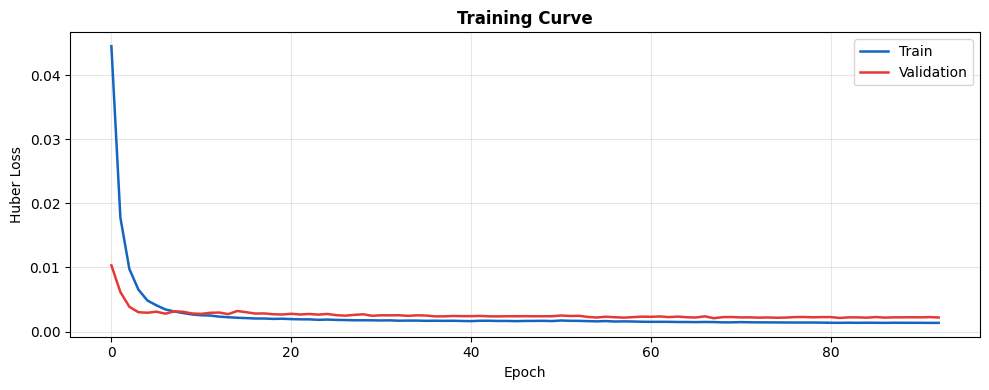

In [77]:
train_losses, val_losses = train_model(model, train_loader, val_loader)

## Evaluation


In [78]:
FEATURE_NAMES = [
    'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close',
    'VWAP', 'Volume', 'Turnover', 'Trades', '%Deliverble'
]

def evaluate(model, X_test, y_test, scaler):
    model.eval()
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

    with torch.no_grad():
        preds_all_scaled = model(X_test_t).cpu().numpy()   # (n, OUTPUT_DAYS, 11)

    preds_scaled = preds_all_scaled[:, :, CLOSE_IDX]       # (n, OUTPUT_DAYS) — Close only

    def inverse_col(arr):
        dummy = np.zeros((len(arr), scaler.n_features_in_))
        dummy[:, CLOSE_IDX] = arr
        return scaler.inverse_transform(dummy)[:, CLOSE_IDX]

    y_close = y_test[:, :, CLOSE_IDX]
    y_orig = inverse_col(y_close.flatten())
    p_orig = inverse_col(preds_scaled.flatten())

    # inverse-transform ALL feature predictions → preds_all_orig (n, OUTPUT_DAYS, 11)
    n, od, nf = preds_all_scaled.shape
    preds_all_orig = scaler.inverse_transform(
        preds_all_scaled.reshape(-1, nf)).reshape(n, od, nf)

    # inverse-transform full input window → X_test_orig (n, INPUT_DAYS, 11)
    n2, id_, nf2 = X_test.shape
    X_test_orig = scaler.inverse_transform(
        X_test.reshape(-1, nf2)).reshape(n2, id_, nf2)

    # actual future values for ALL 11 features → y_all_orig (n, OUTPUT_DAYS, 11)
    base = test_index[0]
    y_all_scaled = np.stack([
        test_scaled[int(test_seq_index[i] - base) - OUTPUT_DAYS + 1 :
                    int(test_seq_index[i] - base) + 1]
        for i in range(n)
    ])
    y_all_orig = scaler.inverse_transform(
        y_all_scaled.reshape(-1, nf)).reshape(n, OUTPUT_DAYS, nf)

    print(f"{'Metric':<8} {'Value':>14}")
    print("-" * 24)
    print(f"{'MSE':<8} {mean_squared_error(y_orig, p_orig):>14.4f}")
    print(f"{'RMSE':<8} {np.sqrt(mean_squared_error(y_orig, p_orig)):>14.4f}")
    print(f"{'MAE':<8} {mean_absolute_error(y_orig, p_orig):>14.4f}")
    print(f"{'R2':<8} {r2_score(y_orig, p_orig):>14.4f}")

    return preds_scaled, p_orig, y_orig, X_test_orig, y_all_orig, preds_all_orig

preds_scaled, preds_orig, y_orig, X_test_orig, y_all_orig, preds_all_orig = \
    evaluate(model, X_test, y_test, scaler)


Metric            Value
------------------------
MSE            722.6072
RMSE            26.8814
MAE             20.7837
R2               0.9628


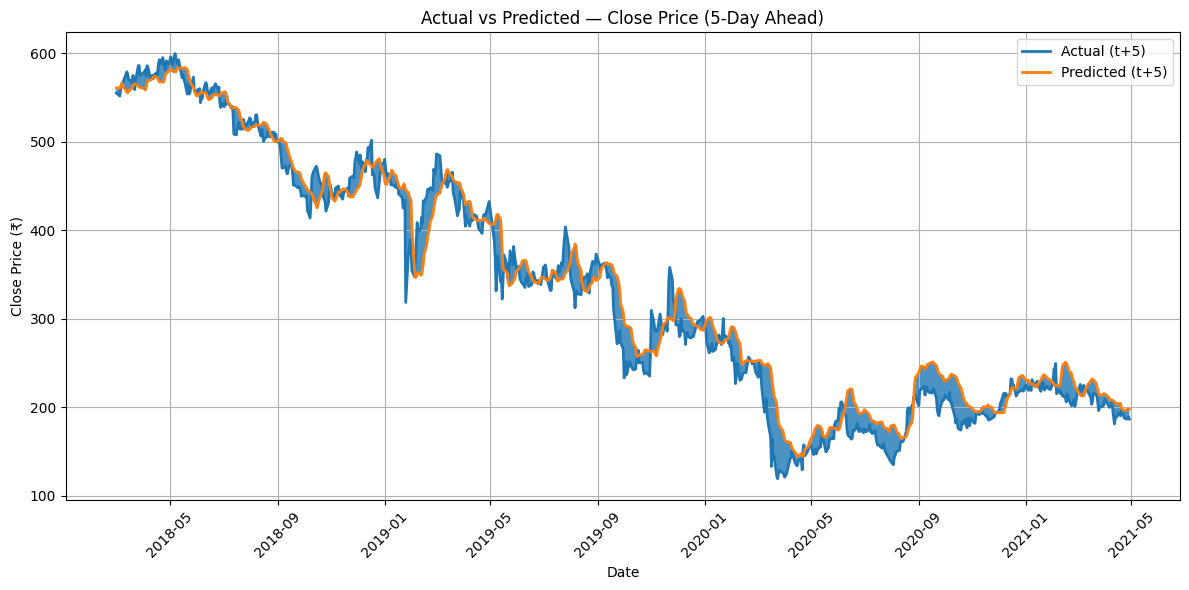

In [79]:
# Actual vs Predicted — Close price, t+5 horizon 
plt.figure(figsize=(12, 6))

actual_seq  = y_orig.reshape(-1, OUTPUT_DAYS)
pred_seq    = preds_orig.reshape(-1, OUTPUT_DAYS)

actual_last = actual_seq[:, -1]
pred_last   = pred_seq[:, -1]

dates = dates_all.iloc[test_seq_index]

plt.plot(dates, actual_last, label="Actual (t+5)",    linewidth=2)
plt.plot(dates, pred_last,   label="Predicted (t+5)", linewidth=2)
plt.fill_between(dates, actual_last, pred_last, alpha=0.8)

plt.title("Actual vs Predicted — Close Price (5-Day Ahead)")
plt.xlabel("Date")
plt.ylabel("Close Price (₹)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()


In [80]:
import pandas as pd

rows = []
for feat_idx, feat_name in enumerate(FEATURE_NAMES):

    actual_t5 = y_all_orig[:, -1, feat_idx]
    pred_t5   = preds_all_orig[:, -1, feat_idx]
    method    = 'LSTM (t+5)'

    mse_v  = mean_squared_error(actual_t5, pred_t5)
    mae_v  = mean_absolute_error(actual_t5, pred_t5)
    rmse_v = np.sqrt(mse_v)
    r2_v   = r2_score(actual_t5, pred_t5)
    mape_v = np.mean(np.abs((actual_t5 - pred_t5) /
                             (np.abs(actual_t5) + 1e-9))) * 100

    rows.append(dict(Feature=feat_name, Method=method,
                     RMSE=rmse_v, MAE=mae_v, R2=r2_v, MAPE_pct=mape_v))

df_errors = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.4f}'.format)
print("\nPer-Feature Prediction Error  (t+5 horizon, all LSTM)")
print("=" * 72)
print(df_errors.to_string(index=False))



Per-Feature Prediction Error  (t+5 horizon, all LSTM)
    Feature     Method                 RMSE                  MAE      R2  MAPE_pct
 Prev Close LSTM (t+5)              30.1160              24.4130  0.9532    9.9358
       Open LSTM (t+5)              33.3629              27.7050  0.9427   11.2204
       High LSTM (t+5)              27.1325              21.6530  0.9624    7.8067
        Low LSTM (t+5)              32.3432              25.0414  0.9452   11.0121
       Last LSTM (t+5)              28.3095              21.4093  0.9585    8.5477
      Close LSTM (t+5)              25.5601              19.4125  0.9662    7.5924
       VWAP LSTM (t+5)              23.8809              18.1567  0.9705    7.0233
     Volume LSTM (t+5)        15587771.3099         7691023.0000  0.1504   54.5901
   Turnover LSTM (t+5) 382717651301757.7500 196009422487552.0000  0.0978   68.3361
     Trades LSTM (t+5)          105762.5222           56747.0117 -0.0725   41.4619
%Deliverble LSTM (t+5)          

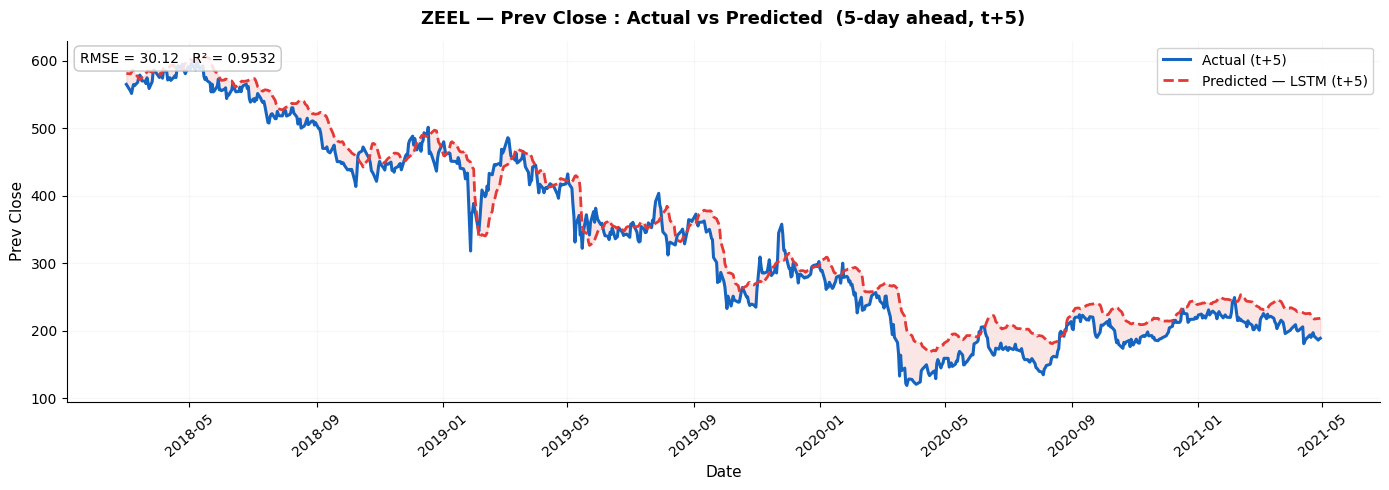

  Saved → feat_00_Prev_Close.png


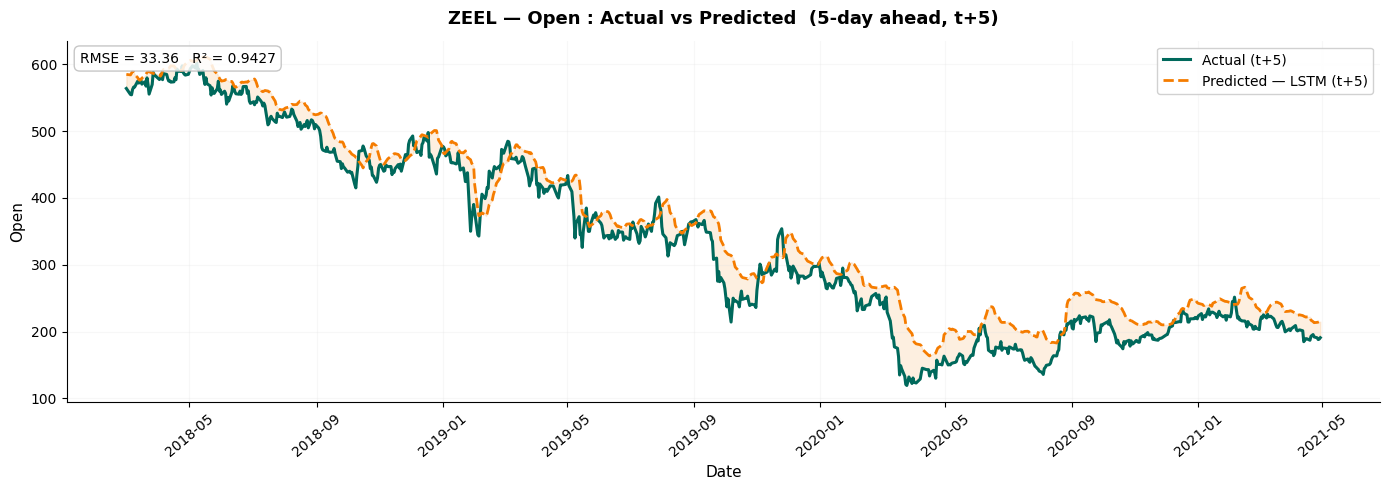

  Saved → feat_01_Open.png


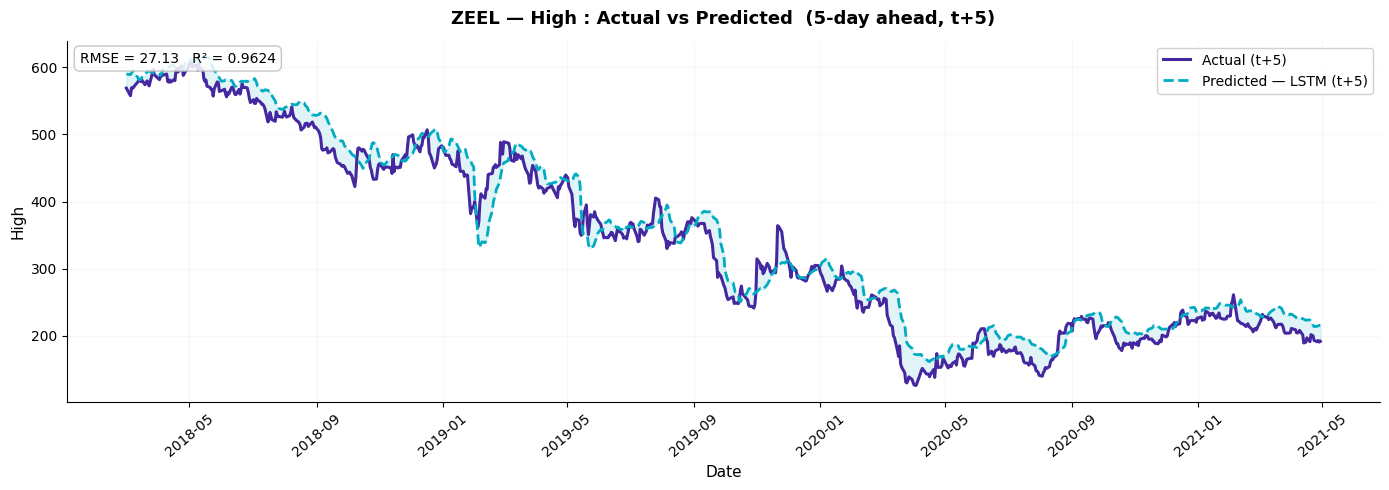

  Saved → feat_02_High.png


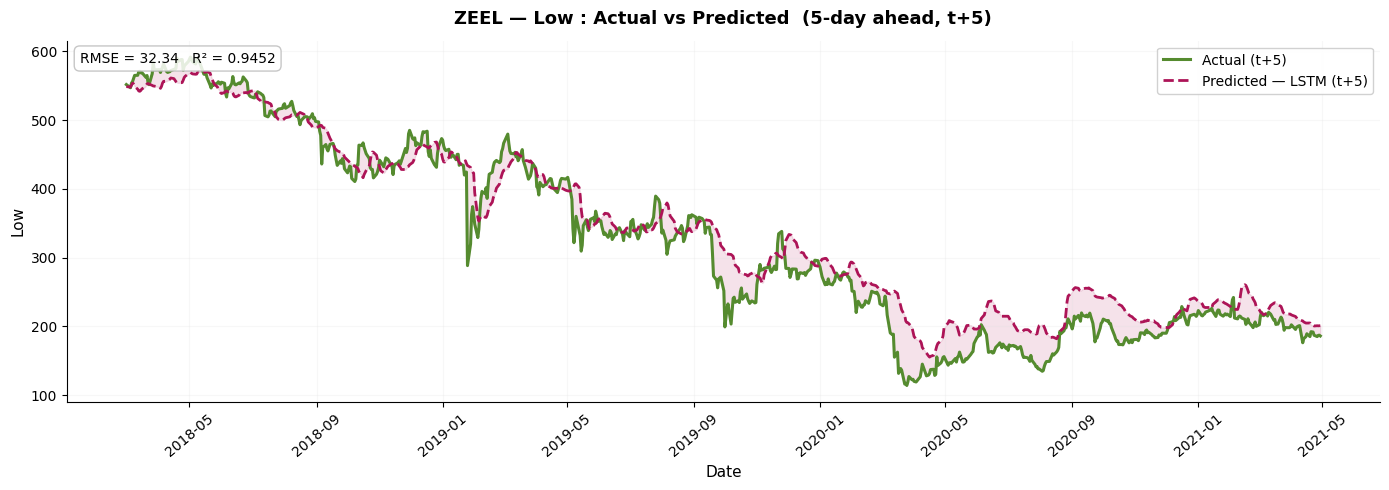

  Saved → feat_03_Low.png


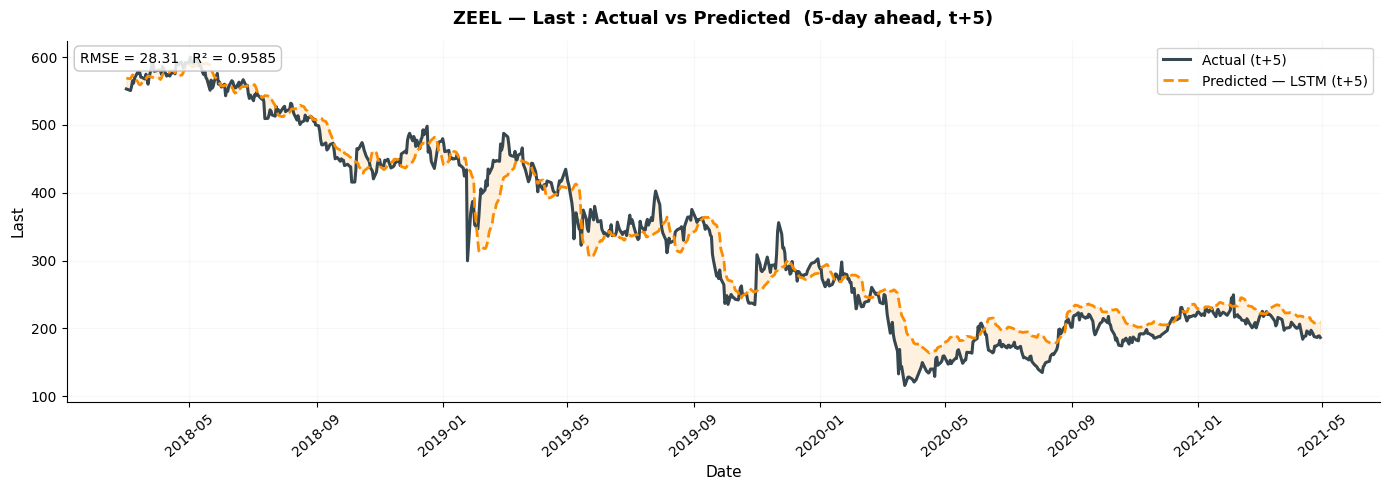

  Saved → feat_04_Last.png


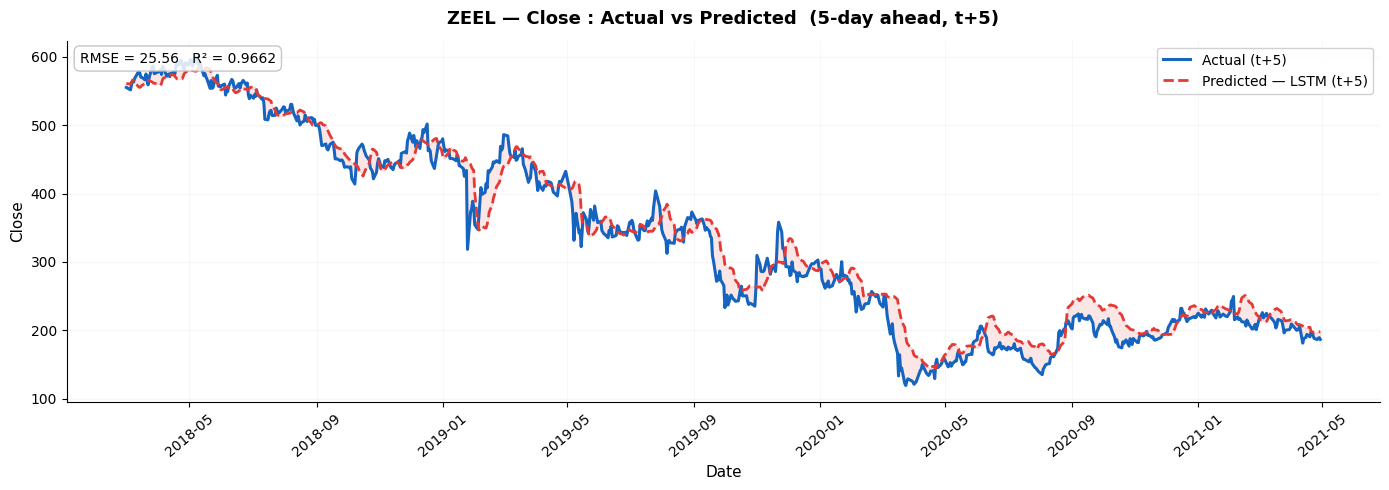

  Saved → feat_05_Close.png


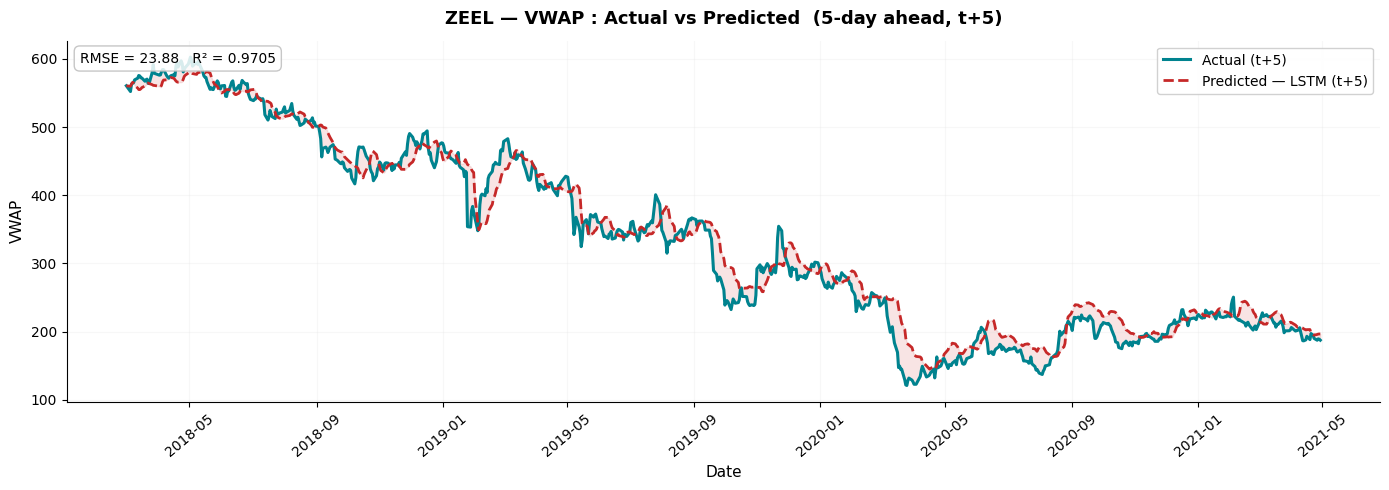

  Saved → feat_06_VWAP.png


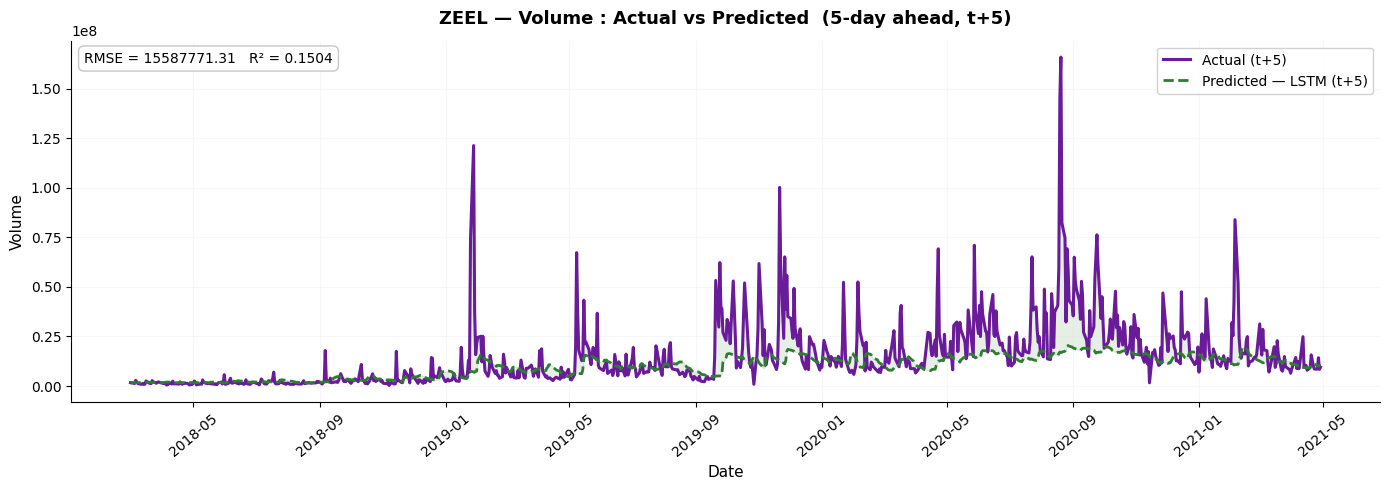

  Saved → feat_07_Volume.png


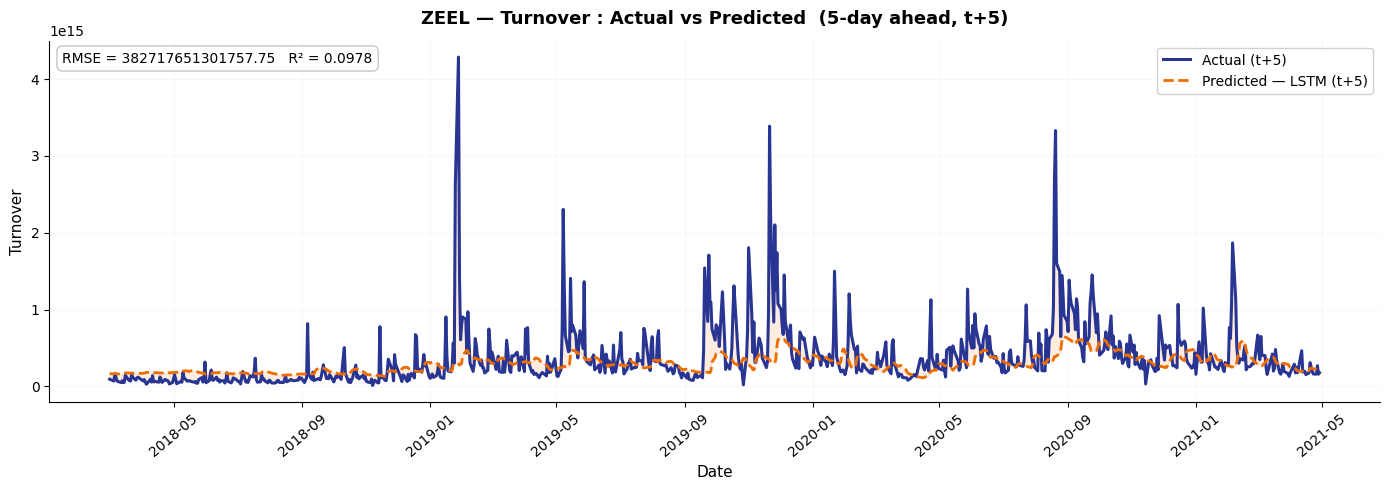

  Saved → feat_08_Turnover.png


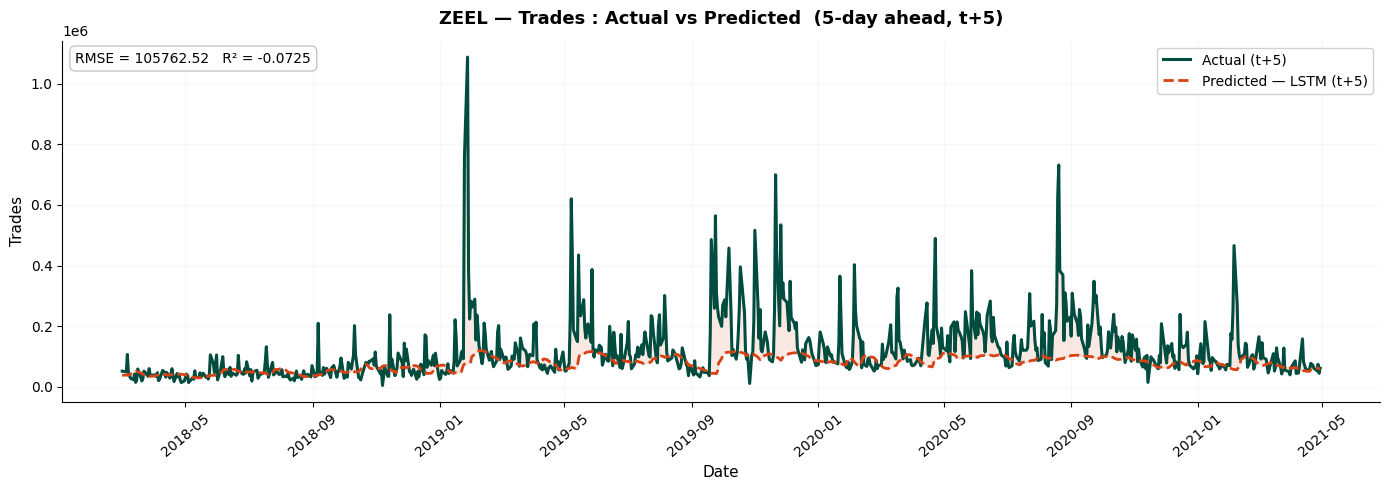

  Saved → feat_09_Trades.png


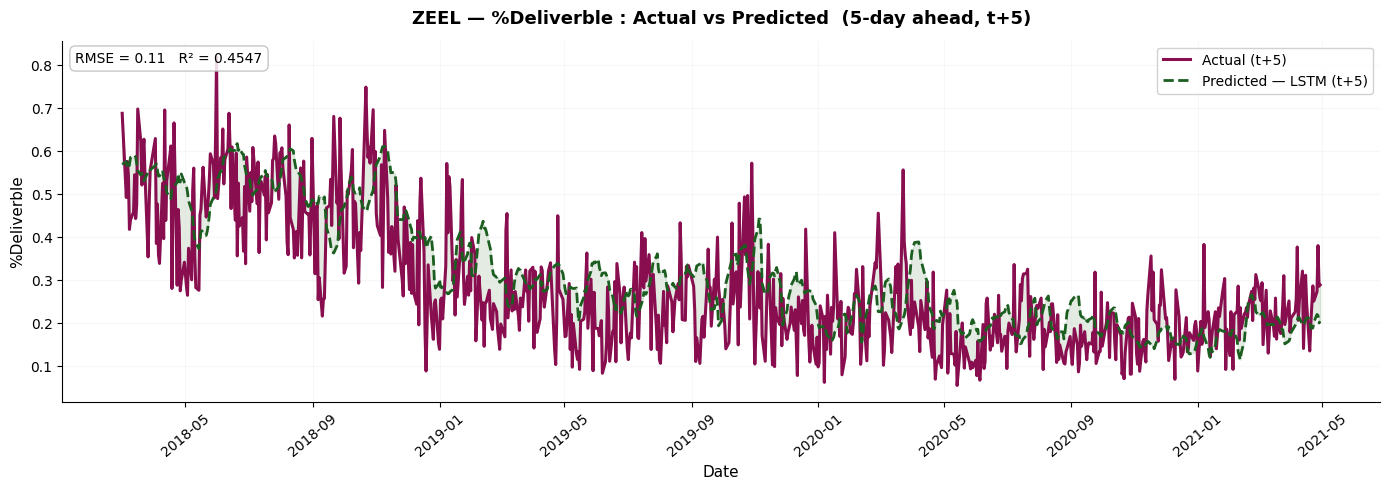

  Saved → feat_10_pctDeliverble.png


In [81]:
import matplotlib.dates as mdates

FEAT_COLORS = [
    ('#1565C0', '#E53935'),   # Prev Close
    ('#00695C', '#F57C00'),   # Open
    ('#4527A0', '#00ACC1'),   # High
    ('#558B2F', '#AD1457'),   # Low
    ('#37474F', '#FB8C00'),   # Last
    ('#1565C0', '#E53935'),   # Close  (LSTM)
    ('#00838F', '#C62828'),   # VWAP
    ('#6A1B9A', '#2E7D32'),   # Volume
    ('#283593', '#EF6C00'),   # Turnover
    ('#004D40', '#D84315'),   # Trades
    ('#880E4F', '#1B5E20'),   # %Deliverble
]

dates = dates_all.iloc[test_seq_index]   # DatetimeIndex, length n

for feat_idx, feat_name in enumerate(FEATURE_NAMES):

    col_act, col_pred = FEAT_COLORS[feat_idx]

    actual_t5 = y_all_orig[:, -1, feat_idx]            # real t+5 value  (n,)

    pred_t5    = preds_all_orig[:, -1, feat_idx]
    pred_label = 'Predicted — LSTM (t+5)'

    rmse_h = np.sqrt(mean_squared_error(actual_t5, pred_t5))
    r2_h   = r2_score(actual_t5, pred_t5)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(dates, actual_t5,
            color=col_act,  linewidth=2.2, label=f'Actual (t+5)',    zorder=3)
    ax.plot(dates, pred_t5,
            color=col_pred, linewidth=2.0, label=pred_label,
            linestyle='--', zorder=3)
    ax.fill_between(dates, actual_t5, pred_t5,
                    color=col_pred, alpha=0.12)

    # metrics box
    info = f'RMSE = {rmse_h:.2f}   R² = {r2_h:.4f}'
    ax.text(0.01, 0.97, info, transform=ax.transAxes,
            fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#BDBDBD', alpha=0.85))

    ax.set_title(f'ZEEL — {feat_name} : Actual vs Predicted  (5-day ahead, t+5)',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel(feat_name, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=40)
    ax.legend(fontsize=10, loc='upper right',
              framealpha=0.9, edgecolor='#CCCCCC')
    ax.grid(alpha=0.25, color='#E0E0E0')
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    fname = feat_name.replace(' ', '_').replace('%', 'pct').replace('/', '_')
    plt.savefig(f'feat_{feat_idx:02d}_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → feat_{feat_idx:02d}_{fname}.png")


## Extra Metrics — MAPE & Directional Accuracy

MAPE gives a percentage error which is easier to interpret for stock prices. Directional accuracy checks whether the model gets the up/down movement right — computed within each 5-day window, not across window boundaries.

In [82]:
def mape(y_true, y_pred):
    # stock prices are always > 0 so no need for epsilon
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAPE :", round(mape(y_orig, preds_orig), 4), "%")

# directional accuracy — checking within each 5-day window, not across windows
actual_seq_dir = y_orig.reshape(-1, OUTPUT_DAYS)
pred_seq_dir   = preds_orig.reshape(-1, OUTPUT_DAYS)

actual_dir = np.sign(np.diff(actual_seq_dir, axis=1))
pred_dir   = np.sign(np.diff(pred_seq_dir,   axis=1))

dir_acc = np.mean(actual_dir == pred_dir) * 100
print(f"Directional Accuracy (within-sequence): {dir_acc:.2f}%")

MAPE : 8.4481 %
Directional Accuracy (within-sequence): 50.70%


## Per-Horizon Plots (t+1 to t+5)

Breaking down predictions by forecast day. Usually t+1 is the easiest and quality drops as you go further out.

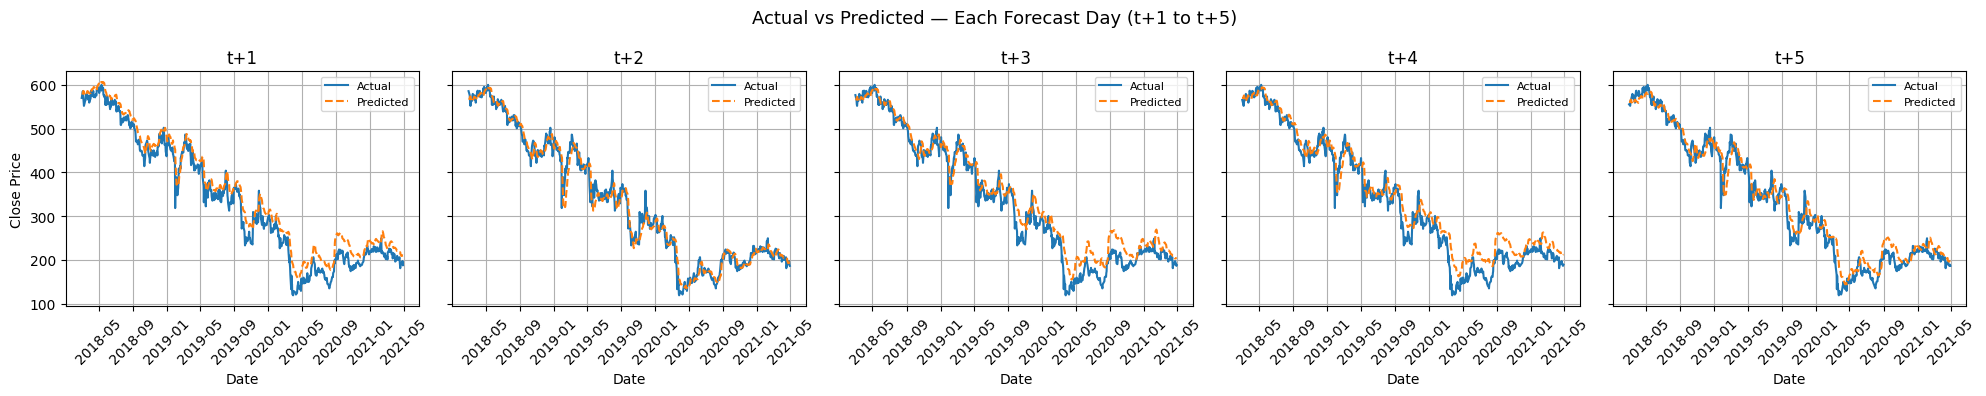

In [83]:
# plot each forecast horizon separately
actual_seq = y_orig.reshape(-1, OUTPUT_DAYS)
pred_seq   = preds_orig.reshape(-1, OUTPUT_DAYS)
dates      = dates_all.iloc[test_seq_index]

fig, axes = plt.subplots(1, OUTPUT_DAYS, figsize=(20, 4), sharey=True)

for i in range(OUTPUT_DAYS):
    axes[i].plot(dates, actual_seq[:, i], label="Actual",    linewidth=1.5)
    axes[i].plot(dates, pred_seq[:, i],   label="Predicted", linewidth=1.5, linestyle="--")
    axes[i].set_title(f"t+{i+1}")
    axes[i].set_xlabel("Date")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid()
    if i == 0:
        axes[i].set_ylabel("Close Price")
    axes[i].legend(fontsize=8)

plt.suptitle("Actual vs Predicted — Each Forecast Day (t+1 to t+5)", fontsize=13)
plt.tight_layout()
plt.show()

## Saving the Model

Saving model weights and the fitted scaler at the end, once everything's been evaluated.

In [85]:
import pickle
import os 
import torch
home_dir = os.path.expanduser("~")
torch.save(model.state_dict(),os.path.join(home_dir, "lstm_zeel.path"))

with open(os.path.join(home_dir, "scaler_zeel.pkl"), "wb") as f:
    pickle.dump(scaler, f)

print("Model saved  → lstm_zeel.pth")
print("Scaler saved → scaler_zeel.pkl")

Model saved  → lstm_zeel.pth
Scaler saved → scaler_zeel.pkl
